## Sensor screening test

Following up on `02_data_exploration.ipynb`:  we run a systematic screening test across several
candidate sensors (PS1, PS2, PS3, EPS1, FS1). For each sensor we measure how
much TiRex2's forecast error drops as the context grows from 1 to 10 cycles,
in two variants (same cycle repeated vs. distinct consecutive real cycles),
averaged over many different starting cycles so the result isn't a fluke.


### Step 1:  stable cycles + common resolution

We keep only cycles where `stable == 0` ("conditions were stable", per the
dataset documentation), and downsample every sensor to 200 points per cycle
using block-averaging (not simple decimation, to avoid aliasing):

- PS1, PS2, PS3, EPS1: 6000 → 200 points (factor 30)
- FS1: 600 → 200 points (factor 3)

Block-averaging smooths out narrow peaks, so we visually compare the raw and
downsampled waveforms of every sensor before trusting them for the screening test.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("data_hydraulic")
SENSORS = ["PS1", "PS2", "PS3", "EPS1", "FS1"]
POINTS = 200


def load_sensor(name: str, data_dir=DATA_DIR) -> np.ndarray:
    return pd.read_csv(data_dir / f"{name}.txt", sep="\t", header=None).values


def downsample(cycles: np.ndarray, n_points: int = POINTS) -> np.ndarray:
    """Block-average each cycle's samples down to n_points (avoids aliasing)."""
    factor = cycles.shape[1] // n_points
    trimmed = cycles[:, : factor * n_points]
    return trimmed.reshape(len(cycles), n_points, factor).mean(axis=2)


profile = pd.read_csv(
    DATA_DIR / "profile.txt", sep="\t", header=None,
    names=["cooler", "valve", "pump_leak", "accumulator", "stable"],
)
stable_idx = np.where(profile["stable"].values == 0)[0]
stable_set = set(stable_idx)
print(f"{len(stable_idx)} / {len(profile)} cycles are stable")

raw = {s: load_sensor(s) for s in SENSORS}
cycles_ds = {s: downsample(raw[s]) for s in SENSORS}
for s in SENSORS:
    print(f"{s}: raw {raw[s].shape} -> downsampled {cycles_ds[s].shape} (factor {raw[s].shape[1] // POINTS})")

1449 / 2205 cycles are stable
PS1: raw (2205, 6000) -> downsampled (2205, 200) (factor 30)
PS2: raw (2205, 6000) -> downsampled (2205, 200) (factor 30)
PS3: raw (2205, 6000) -> downsampled (2205, 200) (factor 30)
EPS1: raw (2205, 6000) -> downsampled (2205, 200) (factor 30)
FS1: raw (2205, 600) -> downsampled (2205, 200) (factor 3)


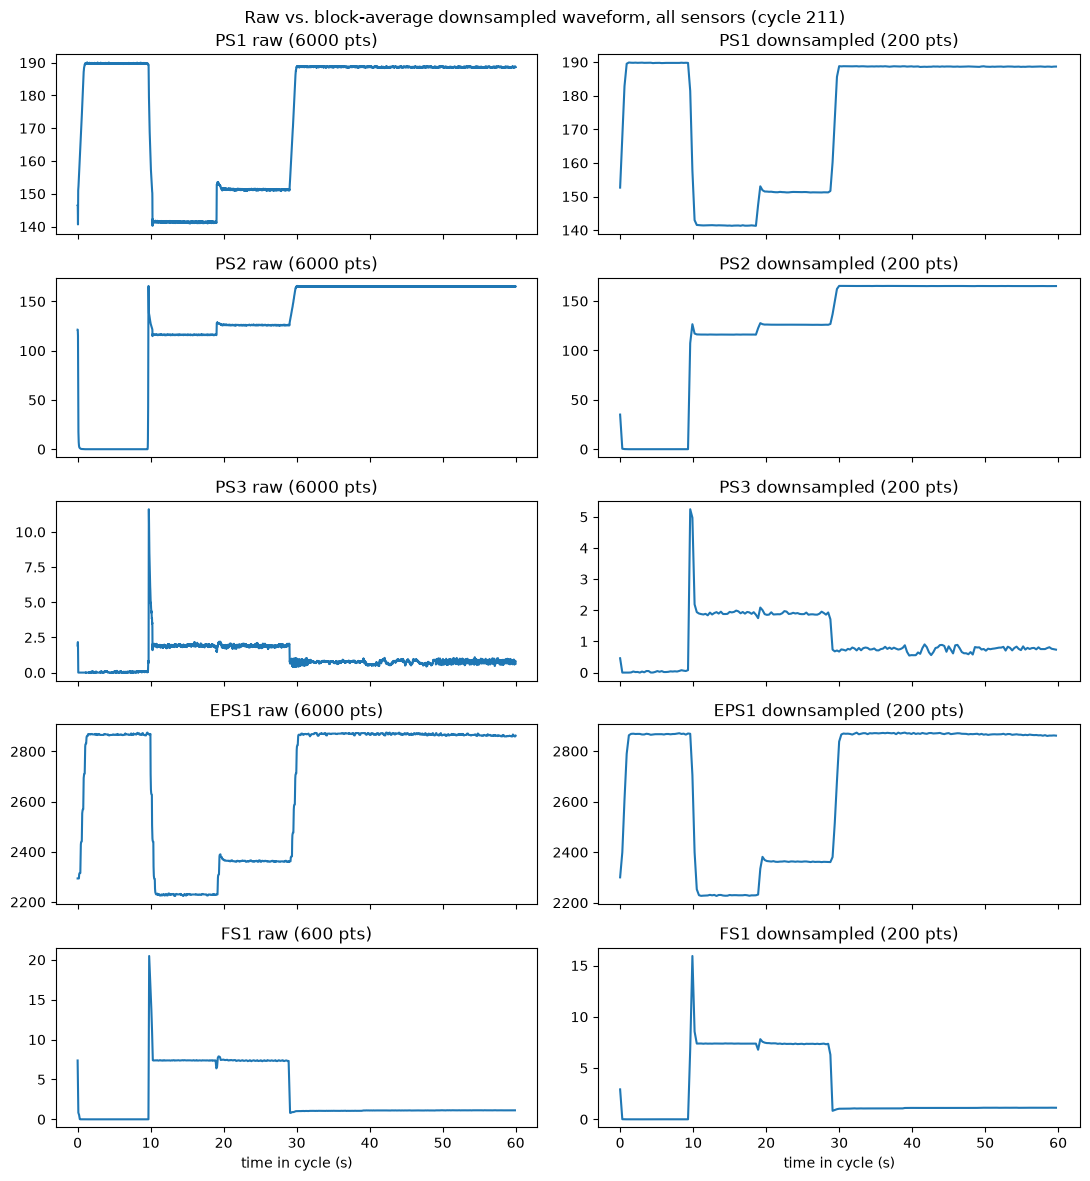

In [6]:
cycle_to_check = stable_idx[0]
CYCLE_SECONDS = 60  # every hydraulic-rig cycle lasts 60 s

fig, axes = plt.subplots(len(SENSORS), 2, figsize=(11, 2.4 * len(SENSORS)), sharex=True)
for row, s in enumerate(SENSORS):
    for col, (data, label) in enumerate([(raw[s], "raw"), (cycles_ds[s], "downsampled")]):
        y = data[cycle_to_check]
        t = np.linspace(0, CYCLE_SECONDS, len(y), endpoint=False)
        axes[row, col].plot(t, y)
        axes[row, col].set_title(f"{s} {label} ({len(y)} pts)")
for ax in axes[-1]:
    ax.set_xlabel("time in cycle (s)")
fig.suptitle(f"Raw vs. block-average downsampled waveform, all sensors (cycle {cycle_to_check})")
fig.tight_layout()
plt.show()

### Step 2 — Screening test

For each sensor, and for context length `n` in {1, 2, 5, 10} cycles, we build
two context variants:

- **same**: the single cycle right before the target, repeated `n` times.
- **different**: the `n` distinct real cycles right before the target,
  concatenated.

We forecast the target cycle's median and compute the normalized error
`MAE / std(true cycle)`, so sensors on very different scales (PS1 ~150 bar
vs. EPS1 ~2500 W) are comparable. This is repeated over many different
target cycles (chosen so their preceding `n` cycles are all stable) to avoid
relying on a single lucky/unlucky case.

In [7]:
import torch
from tirex2 import TimeseriesType, load_model

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("NX-AI/TiRex-2", device=DEVICE)
MEDIAN_QUANTILE_IDX = model.quantiles.shape[0] // 2
print(f"Loaded TiRex2 on device={DEVICE}, median quantile index={MEDIAN_QUANTILE_IDX}")


def forecast_median(context: np.ndarray, h: int = POINTS) -> np.ndarray:
    target = torch.tensor(context, dtype=torch.float32).unsqueeze(0)
    ts = TimeseriesType(target=target, past_covariates=None, future_covariates=None)
    fc = model.forecast([ts], prediction_length=h, output_type="numpy")[0]
    return fc[0, MEDIAN_QUANTILE_IDX]


def screen(cycles: np.ndarray, n_list=(1, 2, 5, 10), n_tests: int = 15, seed: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    max_n = max(n_list)
    # target cycles whose preceding max_n cycles are all stable
    valid = [t for t in stable_idx if all((t - k) in stable_set for k in range(1, max_n + 1))]
    tests = rng.choice(valid, size=min(n_tests, len(valid)), replace=False)
    rows = []
    for t in tests:
        truth = cycles[t]
        for n in n_list:
            ctx_same = np.tile(cycles[t - 1], n)
            ctx_diff = np.concatenate(cycles[t - n : t])
            for mode, ctx in [("same", ctx_same), ("different", ctx_diff)]:
                pred = forecast_median(ctx)
                nmae = np.mean(np.abs(pred - truth)) / (truth.std() + 1e-8)
                rows.append({"cycle": t, "n_cycles": n, "mode": mode, "nMAE": nmae})
    return pd.DataFrame(rows)


results = []
for s in SENSORS:
    df = screen(cycles_ds[s])
    df["sensor"] = s
    results.append(df)
results = pd.concat(results, ignore_index=True)

summary = results.groupby(["sensor", "mode", "n_cycles"])["nMAE"].mean().unstack("n_cycles").round(3)
summary

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1659.80it/s]


Loaded TiRex2 on device=mps, median quantile index=4


n_cycles             1      2      5      10
sensor mode                                 
EPS1   different  0.832  0.482  0.177  0.176
       same       0.832  0.476  0.141  0.133
FS1    different  0.561  0.480  0.163  0.133
       same       0.561  0.467  0.137  0.129
PS1    different  0.832  0.488  0.179  0.189
       same       0.832  0.465  0.138  0.136
PS2    different  0.542  0.128  0.067  0.055
       same       0.542  0.100  0.064  0.055
PS3    different  0.542  0.440  0.143  0.134
       same       0.542  0.449  0.141  0.130

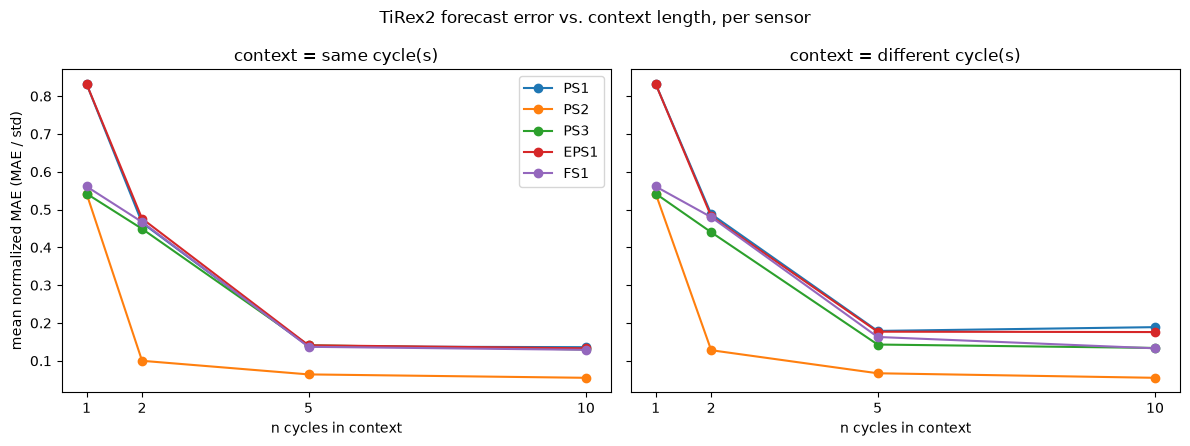

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, mode in zip(axes, ["same", "different"]):
    for s in SENSORS:
        sub = summary.loc[(s, mode)]
        ax.plot(sub.index, sub.values, marker="o", label=s)
    ax.set_title(f"context = {mode} cycle(s)")
    ax.set_xlabel("n cycles in context")
    ax.set_xticks(list(summary.columns))
axes[0].set_ylabel("mean normalized MAE (MAE / std)")
axes[0].legend()
fig.suptitle("TiRex2 forecast error vs. context length, per sensor")
fig.tight_layout()
plt.show()

### Forecast vs. ground truth, per sensor

For context lengths `n` in {1, 2, 5} cycles we show what TiRex2 actually forecasts.
One fixed stable target cycle is used for every sensor and every `n`, so the grids are
directly comparable. The context is the cycle right before the target, repeated `n` times
(the "same" variant). Each subplot title reports the normalized MAE of that forecast.

target cycle: 231


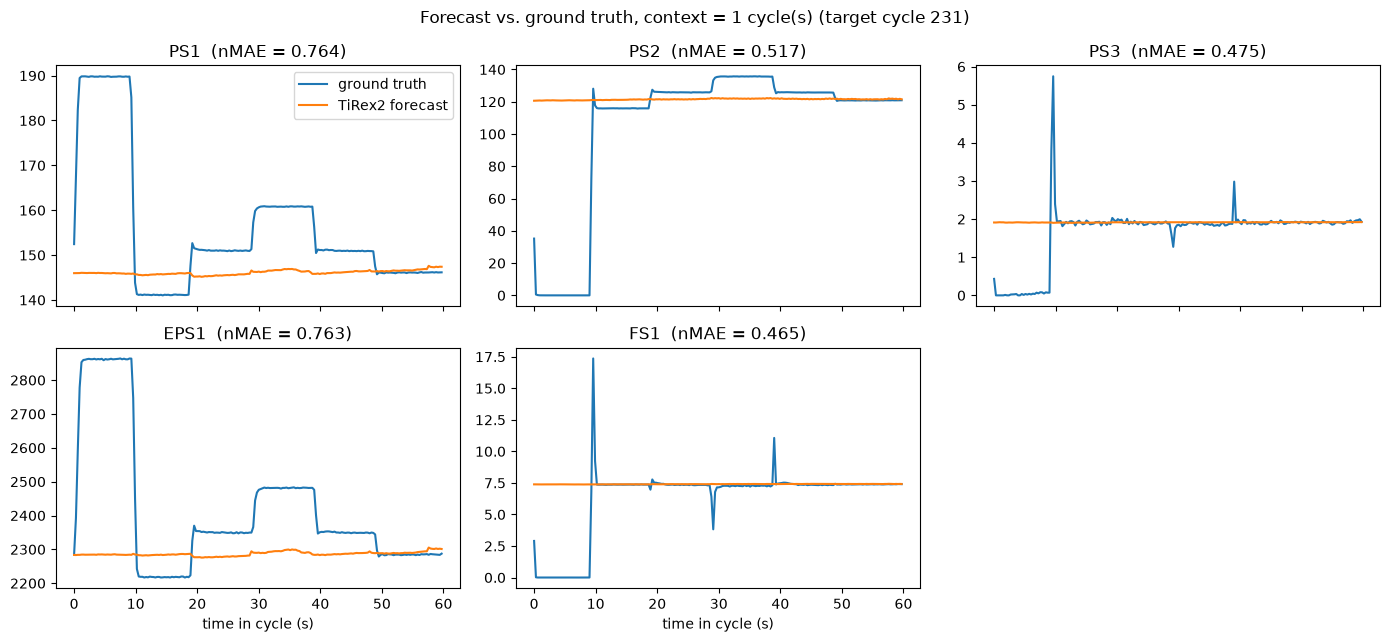

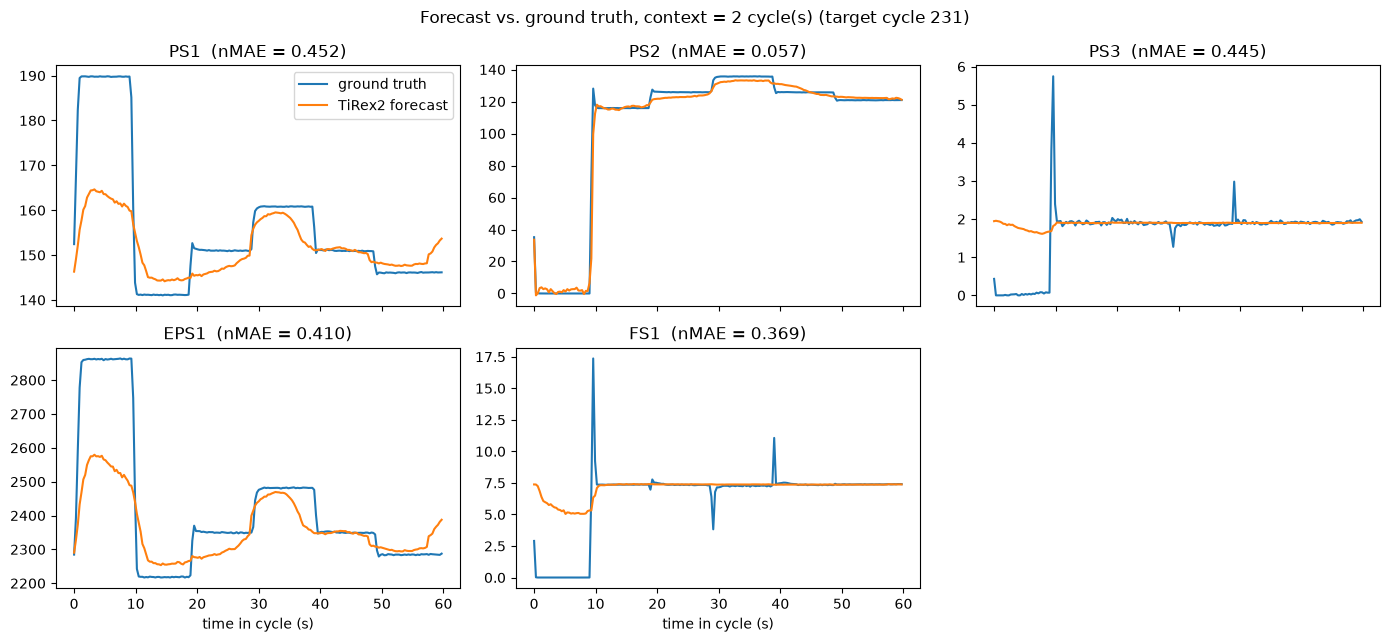

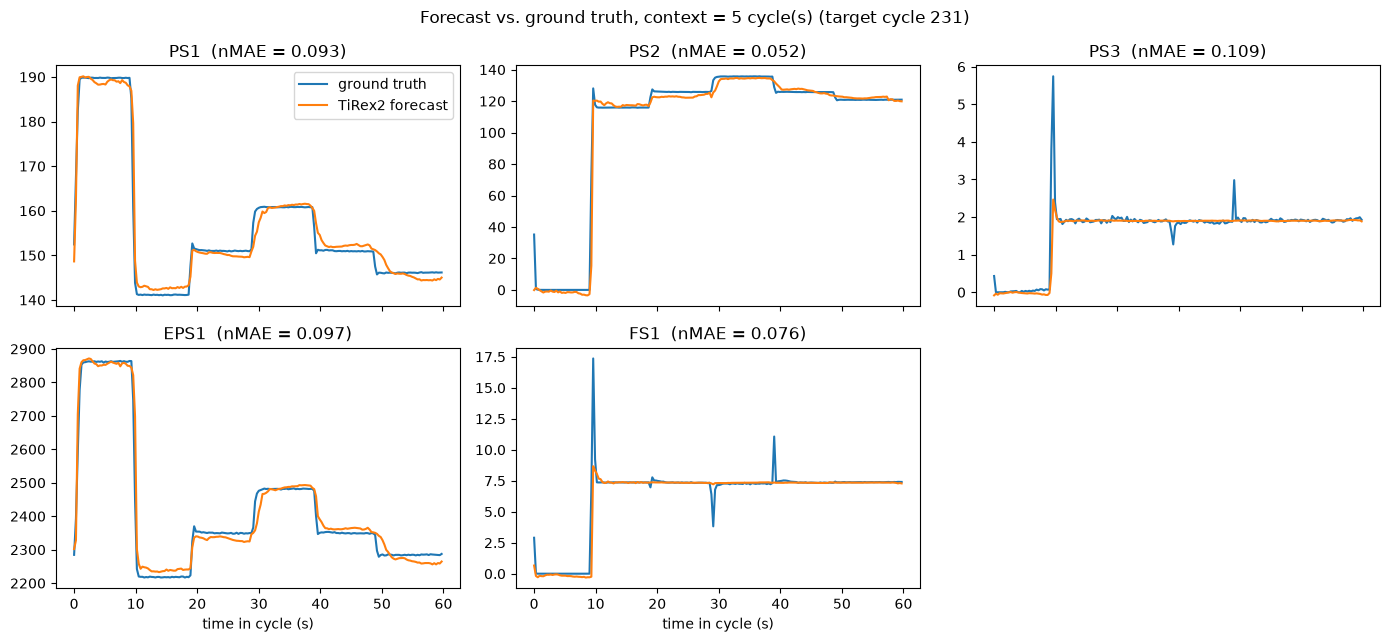

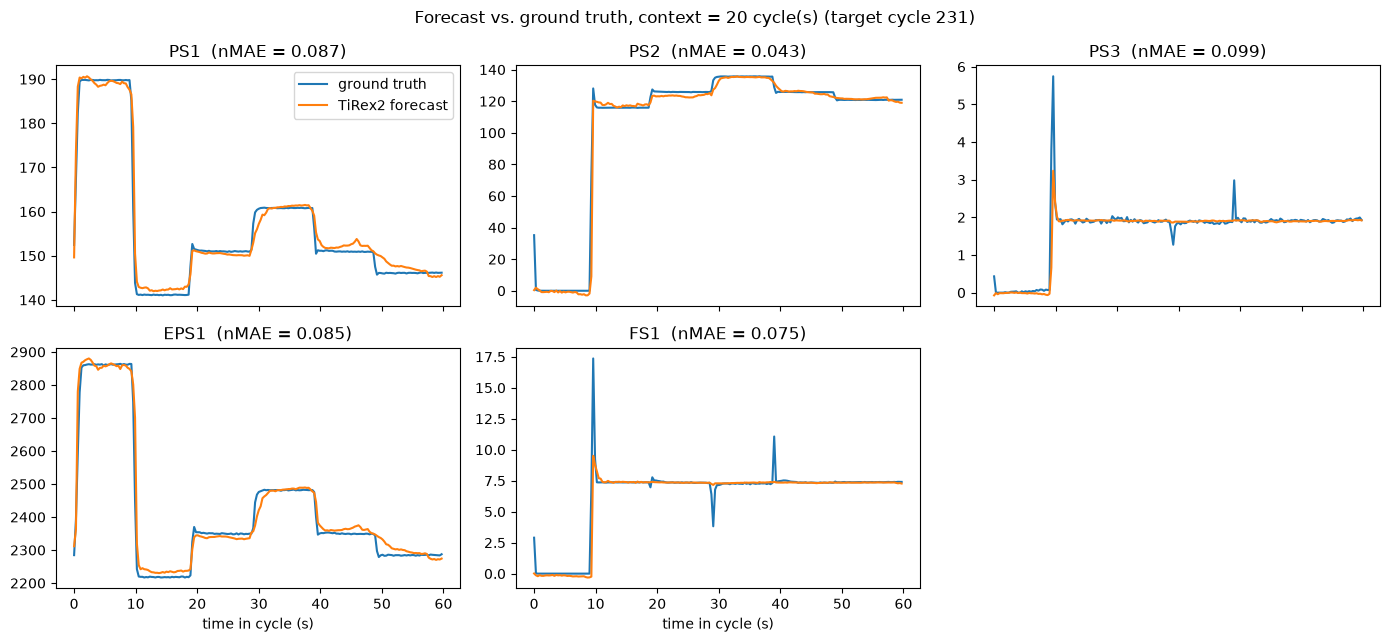

In [13]:
N_LIST = (1, 2, 5, 20)
MAX_N = max(N_LIST)

# first stable cycle whose preceding MAX_N cycles are all stable (same rule as screen())
target_cycle = next(t for t in stable_idx if all((t - k) in stable_set for k in range(1, MAX_N + 1)))
t_axis = np.linspace(0, CYCLE_SECONDS, POINTS, endpoint=False)
print(f"target cycle: {target_cycle}")

for n in N_LIST:
    fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharex=True)
    axes = axes.ravel()
    for ax, s in zip(axes, SENSORS):
        truth = cycles_ds[s][target_cycle]
        pred = forecast_median(np.tile(cycles_ds[s][target_cycle - 1], n))
        nmae = np.mean(np.abs(pred - truth)) / (truth.std() + 1e-8)
        ax.plot(t_axis, truth, label="ground truth")
        ax.plot(t_axis, pred, label="TiRex2 forecast")
        ax.set_title(f"{s}  (nMAE = {nmae:.3f})")
    for ax in axes[len(SENSORS):]:
        ax.axis("off")
    for ax in axes[3:len(SENSORS)]:
        ax.set_xlabel("time in cycle (s)")
    axes[0].legend()
    fig.suptitle(f"Forecast vs. ground truth, context = {n} cycle(s) (target cycle {target_cycle})")
    fig.tight_layout()
    plt.show()

### TAKE AWAY
By analysing the above plot the best candidate for the documentation is : PS1 and EPS1 as they have the biggest difference between 1 cycle and 5 cycle context
- in the documentation we can show 1 cycle vs 2 cycles vs 5 cycles context 
- 10 cycles is too similar to 5 cycles --> not relevant